In [3]:
!pip install owlready2

You should consider upgrading via the 'C:\Users\hallo\Desktop\Bainitu_segmenation\venv\Scripts\python.exe -m pip install --upgrade pip' command.



  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
    Preparing wheel metadata: started
    Preparing wheel metadata: finished with status 'done'
  Created wheel for owlready2: filename=owlready2-0.49-py3-none-any.whl size=23376594 sha256=2ef8f8f9cad8d5b70e4648b8684b87e7758bdbd3aa98f4d8e31048e3c052d1a5
  Stored in directory: c:\users\hallo\appdata\local\pip\cache\wheels\f4\0f\12\701a9e03ce58ccf43305b61056ce0360b004230eb7571ebdeb
Successfully built owlready2


In [6]:
from owlready2 import *

# Create a new ontology
onto = get_ontology("http://example.org/lm_microstructure_physics.owl")

with onto:
    # Classes
    class HeatTreatmentProcess(Thing): pass
    class SampleGeometry(Thing): pass
    class MicrostructurePhase(Thing): pass
    class MetallurgicalRule(Thing): pass

    # Subclasses for processes
    class IsothermalHold(HeatTreatmentProcess): pass
    class DirectQuenching(HeatTreatmentProcess): pass

    # Subclasses for geometry
    class FullSample(SampleGeometry): pass
    class HollowSample(SampleGeometry): pass

    # Subclasses for phases
    class UpperBainite(MicrostructurePhase): pass
    class LowerBainite(MicrostructurePhase): pass
    class Martensite(MicrostructurePhase): pass

    # Properties
    class allowedPhase(HeatTreatmentProcess >> MicrostructurePhase): pass
    class suppressedPhase(SampleGeometry >> MicrostructurePhase): pass
    class contradicts(MicrostructurePhase >> MicrostructurePhase): pass

    # Define physics / logic rules
    # Upper bainite only forms under isothermal hold
    IsothermalHold.allowedPhase = [UpperBainite, LowerBainite]
    DirectQuenching.allowedPhase = [LowerBainite, Martensite]

    # Geometry constraints
    HollowSample.suppressedPhase = [UpperBainite, LowerBainite]
    FullSample.suppressedPhase = []

    # Example contradictory phases (cannot coexist in same location)
    UpperBainite.contradicts = [Martensite]
    Martensite.contradicts = [UpperBainite]
    LowerBainite.contradicts = []

# Optional: save ontology
onto.save(file = "lm_microstructure_physics.owl")

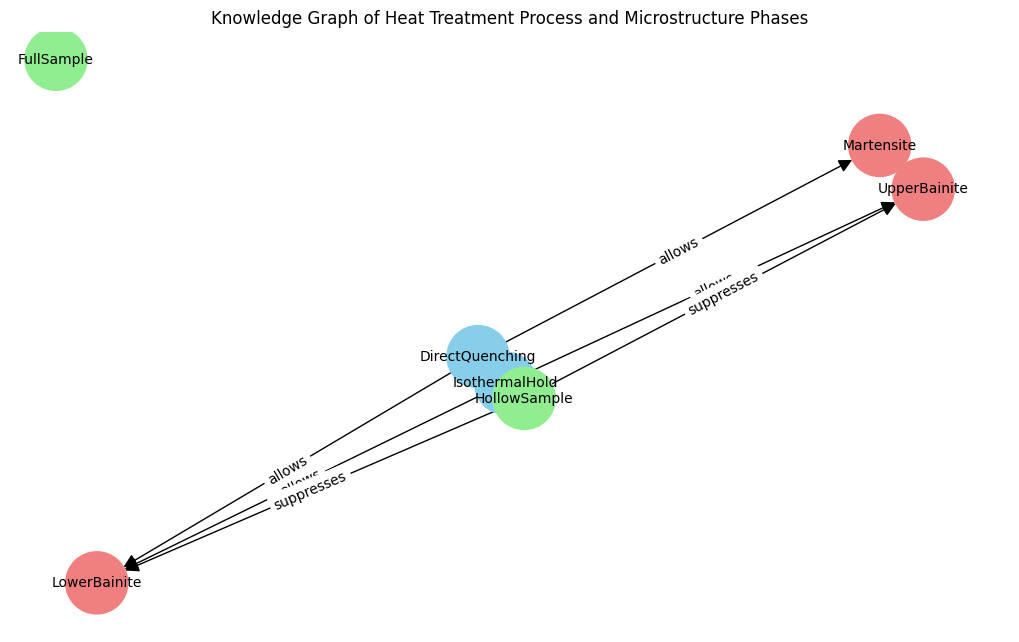

In [8]:
from owlready2 import *
import networkx as nx
import matplotlib.pyplot as plt

# Load the ontology
onto = get_ontology("lm_microstructure_physics.owl").load()

# Create directed graph
G = nx.DiGraph()

# Add processes and their allowed phases
for process in onto.HeatTreatmentProcess.subclasses():
    G.add_node(process.name, type='process')
    for phase in process.allowedPhase:
        G.add_node(phase.name, type='phase')
        G.add_edge(process.name, phase.name, label='allows')

# Add geometries and suppressed phases
for geom in onto.SampleGeometry.subclasses():
    G.add_node(geom.name, type='geometry')
    for phase in geom.suppressedPhase:
        G.add_node(phase.name, type='phase')
        G.add_edge(geom.name, phase.name, label='suppresses')

# Add contradictory phases
for phase in onto.MicrostructurePhase.subclasses():
    for c in phase.contradicts:
        G.add_edge(phase.name, c.name, label='contradicts', style='dashed')

# Plot
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10,6))
node_colors = []
for node in G.nodes():
    if node in [p.name for p in onto.HeatTreatmentProcess.subclasses()]:
        node_colors.append('skyblue')
    elif node in [g.name for g in onto.SampleGeometry.subclasses()]:
        node_colors.append('lightgreen')
    else:
        node_colors.append('lightcoral')

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=2000, font_size=10, arrowsize=20)
edge_labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black')
plt.title('Knowledge Graph of Heat Treatment Process and Microstructure Phases')
plt.axis('off')
plt.show()


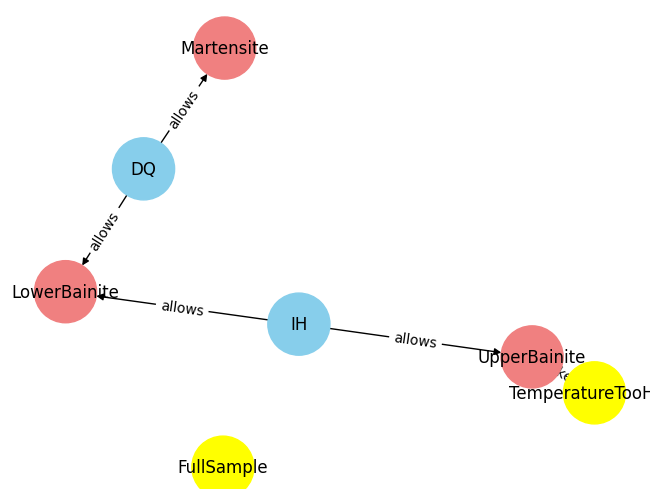

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Nodes
G.add_node("DQ", type="process")
G.add_node("IH", type="process")
G.add_node("FullSample", type="geometry")
G.add_node("LowerBainite", type="phase")
G.add_node("UpperBainite", type="phase")
G.add_node("Martensite", type="phase")
G.add_node("TemperatureTooHigh", type="condition")

# Edges
G.add_edge("DQ", "LowerBainite", label="allows")
G.add_edge("DQ", "Martensite", label="allows")
G.add_edge("IH", "LowerBainite", label="allows")
G.add_edge("IH", "UpperBainite", label="allows")
G.add_edge("UpperBainite", "TemperatureTooHigh", label="blockedBy")

# Draw
pos = nx.spring_layout(G, seed=42)
colors = []
for node in G.nodes():
    t = G.nodes[node]['type']
    if t == 'process': colors.append('skyblue')
    elif t == 'phase': colors.append('lightcoral')
    else: colors.append('yellow')

nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()
